# Этап 2. Предварительная обработка данных

**Цель:** подготовить объявления предполагаемой продажи к обучению моделей. Исторические цены EUR, USD и GBP пересчитываем в TRY по официальным курсам TCMB; аренду и нерасшифрованный тип 3 не смешиваем с продажей. Код 1 по уровню цен похож на продажу, но исходный словарь не расшифровывает числовые коды — это ограничение проекта.

Все преобразования, которым нужно вычислить медианы, пороги или частоты категорий, обучаются только на train. Исходный CSV остаётся без изменений. Курсы — фиксированный внешний справочник, а не статистика из validation/test.


## Подготовка окружения

Конвейер предобработки находится в модуле src/preprocessing.py. Это нужно, чтобы на следующем этапе точно те же операции применялись к train, validation, test и данным приложения.

In [1]:
# Импортируем модуль из корня проекта, независимо от текущей папки Jupyter.
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / "src" / "preprocessing.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Откройте ноутбук из папки проекта или notebooks")
sys.path.insert(0, str(ROOT))
from src.exchange_rates import convert_sale_prices
from src.preprocessing import (
    RANDOM_STATE, NUMERIC_FEATURES, CATEGORICAL_FEATURES, FORBIDDEN_INPUTS,
    PropertyFeatureBuilder, GroupMedianAreaImputer, QuantileCapper,
    select_sale_try, split_sale_data, make_preprocessor,
)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
def show_table(frame):
    display(frame.style.hide(axis="index").format(precision=2, thousands=" ", na_rep="—"))
raw = pd.read_csv(ROOT / "data" / "real_estate_data.csv", low_memory=False)
rates = pd.read_csv(ROOT / "data" / "external" / "tcmb_rates_2018-2019.csv")
normalized = convert_sale_prices(raw, rates)
sale = select_sale_try(normalized)
print(f"Исходный набор: {len(raw):,} строк; сопоставимый сегмент: {len(sale):,} строк")
print("Версии:", "pandas", pd.__version__)

Исходный набор: 403,487 строк; сопоставимый сегмент: 286,392 строк
Версии: pandas 2.3.3


### Почему мы оставляем только код объявления 1

Задача модели — прогнозировать **цену предполагаемой продажи в TRY**, а не смешивать продажу, аренду и неизвестный тип. Справочник к датасету упоминает продажи (*Satılık*) и аренду (*Kiralık*), но **не расшифровывает числовые коды** listing_type. Следовательно, соответствие кодов — интерпретация по масштабу цен.

| Код listing_type | Записей в исходном наборе | Медианная цена в TRY | Решение |
|---|---:|---:|---|
| 1 | 287 009 | 270 000 | Похоже на продажу; оставляем положительные цены в поддерживаемых валютах. |
| 2 | 114 236 | 1 200 | Похоже на аренду; не смешиваем с продажей, поскольку это другой тип платежа. |
| 3 | 2 242 | 70 | Значение не расшифровано; не включаем в модель продажи. |

**Почему другие валюты теперь включены:** в отличие от предыдущей версии, цены EUR, USD и GBP пересчитываются в TRY по историческим курсам на даты публикации. Перевод единиц измерения не меняет смысл аренды и не доказывает значение кодов.


### Источник и правило пересчёта валюты

Источник: [архив индикативных курсов Центрального банка Турции (TCMB)](https://www.tcmb.gov.tr/kurlar/kurlar_en.html). Локальная копия за 27.08.2018–27.02.2019: data/external/tcmb_rates_2018-2019.csv. В архивных XML-файлах использовано поле **ForexBuying** (TRY за единицу валюты; с учётом Unit). Один и тот же тип курса применён ко всем объявлениям для воспроизводимости. Это справочный курс, а не гарантированный курс фактической сделки.

Для даты публикации берётся курс этой даты; если он не опубликован в выходной или праздник — последний опубликованный **до** неё, максимум за 7 дней. Курсы более поздних календарных дат не используются. В датасете нет времени публикации: курс того же дня мог появиться позже самого объявления. Это ограничение пересчёта. Исходная валюта, курс и дата курса сохраняются для аудита, но **не подаются модели как признаки**. Цены TRY не меняются.


In [2]:
# Проверяем охват официальных курсов и результат пересчёта.
foreign = sale[sale["original_currency"].ne("TRY")].copy()
lag_days = (pd.to_datetime(foreign["start_date"], format="%m/%d/%y")
            - pd.to_datetime(foreign["rate_date"])).dt.days
currency_audit = sale.groupby("original_currency").agg(
    **{"Объявлений": ("price", "size"),
       "Медиана после пересчёта, TRY": ("price", "median")}
).reset_index().rename(columns={"original_currency": "Исходная валюта"})
show_table(currency_audit)
print("Всего после отбора:", len(sale))
print("Пересчитано валютных объявлений:", len(foreign))
print("Без подходящего курса:", foreign["rate_date"].isna().sum())
print("Максимальное отставание курса, дней:", lag_days.max())
print("Неизменных цен TRY:", (sale.loc[sale.original_currency.eq("TRY"), "price"]
                                == raw.loc[sale.loc[sale.original_currency.eq("TRY")].index, "price"]).all())
assert len(sale) == 286392
assert len(foreign) == 1924 and foreign["rate_date"].notna().all()
assert lag_days.between(0, 7).all()
assert (sale["price"] > 0).all()


Исходная валюта,Объявлений,"Медиана после пересчёта, TRY"
EUR,891,568 917.00
GBP,581,537 212.70
TRY,284 468,270 000.00
USD,452,3 673 835.00


Всего после отбора: 286392
Пересчитано валютных объявлений: 1924
Без подходящего курса: 0
Максимальное отставание курса, дней: 3
Неизменных цен TRY: True


Из **287 009** объявлений с кодом 1 осталось **286 392** с положительной ценой: **284 468** исходно в TRY и **1 924** пересчитанных из EUR, GBP и USD. Значит, фильтр цены исключил 617 строк. Все валютные объявления получили курс, максимальное отставание курса от даты публикации — **3 дня**; исходные цены TRY не изменились. Пересчитанные цены нельзя трактовать как фактическую сумму сделки: это сопоставимые *цены объявлений* по справочному курсу.


В итоговом сегменте **286 392** объявления. Строки с пустой или неположительной целевой ценой исключены: целевую переменную нельзя корректно заполнить медианой. Пропуски в признаках обрабатываются ниже, без удаления этих строк.


## 2.1. Работа с пропусками

Стратегия выбирается по смыслу каждого поля. Список ниже задаёт решения; обучаемые заполнители будут применены только после разбиения в разделе 2.6.

| Поле | Решение | Почему |
|---|---|---|
| price | Исключить пустые и неположительные цены до разбиения | Без корректной цели нельзя обучить регрессию |
| furnished | Удалить столбец | Он пуст на 100% |
| end_date | Не использовать | Дата снятия часто отсутствует и неизвестна при публикации |
| size | Значения менее 15 м² считать неизвестными; заполнять медианой район+тип, затем город+тип, тип и общей медианой train | Пропусков много, удаление строк уничтожит треть набора; локальная медиана учитывает различия жилья |
| building_age, total_floor_count, floor_no, room_count | Преобразовать в числа; остаточные пропуски заполнить медианой train | Смешанные числовые и текстовые формы, медиана устойчива к выбросам |
| heating_type и другие категориальные | Заполнить самой частой категорией train | Сохраняем строку; способ прост и воспроизводим |
| price_currency, listing_type, type | Не использовать как признаки | Валюта стала TRY после пересчёта, тип объявления отобран; type везде означает жильё |
| id | Не использовать как признак | Это технический идентификатор |
| tom | Не использовать | Срок объявления становится известен позже и может вызвать утечку |

KNNImputer здесь не выбран: при сотнях тысяч строк и десятках процентов пустой площади он намного дороже, а групповые медианы проще проверить и объяснить.

In [3]:
# Доля пропусков в выбранном сегменте до каких-либо заполнений.
missing = pd.DataFrame({
    "Поле": sale.columns,
    "Пустых": sale.isna().sum().values,
    "Доля, %": sale.isna().mean().mul(100).values,
}).sort_values("Доля, %", ascending=False)
show_table(missing)

Поле,Пустых,"Доля, %"
furnished,286 392,100.00
rate_date,284 468,99.33
end_date,103 119,36.01
size,101 702,35.51
floor_no,24 721,8.63
total_floor_count,18 314,6.39
heating_type,18 272,6.38
building_age,17 242,6.02
start_date,0,0.00
sub_type,0,0.00


Площадь — главный недостающий полезный признак. Удаление всех строк без неё серьёзно уменьшило бы набор и могло бы сместить выборку. Полностью пустую меблировку восстановить из этих данных нельзя.

In [4]:
# Показываем, какие новые признаки можно построить без статистики train.
builder = PropertyFeatureBuilder()
preview = builder.transform(sale.drop(columns=["price"]).head(8))
show_table(preview.reset_index(drop=True))

size_m2,bedrooms,living_rooms,building_age_years,building_floors,floor_number,floor_ratio,size_missing,age_missing,is_new_building,is_top_floor,city,district,sub_type,heating_type,floor_kind
43.00,1,0,0.00,20.00,20.00,1.00,0.00,0.00,1.00,0.00,İstanbul,İstanbul/Kartal,Daire,Fancoil,other
—,2,1,0.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,Tekirdağ,Tekirdağ/Çorlu,Daire,Fancoil,entrance
450.00,6,1,3.00,20.00,20.00,1.00,0.00,0.00,0.00,0.00,İstanbul,İstanbul/Beşiktaş,Rezidans,Fancoil,other
90.00,2,1,0.00,20.00,2.00,0.10,0.00,0.00,1.00,0.00,İstanbul,İstanbul/Kartal,Rezidans,Fancoil,numbered
45.00,1,1,2.00,15.00,10.00,0.67,0.00,0.00,0.00,0.00,İstanbul,İstanbul/Maltepe,Rezidans,Fancoil,numbered
—,4,1,0.00,4.00,—,—,1.00,0.00,1.00,0.00,İzmir,İzmir/Urla,Villa,Fancoil,—
140.00,3,1,—,2.00,-2.00,-1.00,0.00,1.00,0.00,0.00,Çanakkale,Çanakkale/Ayvacık,Daire,Fancoil,basement
550.00,2,2,1.00,1.00,—,—,0.00,0.00,0.00,0.00,İstanbul,İstanbul/Fatih,Daire,Fancoil,mezzanine


Поля уже разобраны в числовые и категориальные: например, из адреса получены город и район, из 2+1 — комнаты и гостиная. Это только разбор исходной записи; статистики для заполнения здесь ещё не обучались.

## 2.2. Обработка выбросов

Выбор: удаляем только строки с некорректной целевой ценой; площадь менее 15 м² считаем неизвестной; положительные экстремальные цены пока сохраняем. Площадь ограничим по **0,1-му и 99,9-му перцентилям train**. Цену не ограничиваем, чтобы тестовые ошибки оставались честными. Для обучения моделей на следующем этапе проверим логарифмирование цены через TransformedTargetRegressor.

In [5]:
# Квантили показывают масштаб хвоста цены и площади до обработки.
quantiles = pd.DataFrame({
    "Перцентиль": ["0,1%", "1%", "50%", "99%", "99,9%", "максимум"],
    "Цена, TRY": [sale.price.quantile(q) for q in [0.001,0.01,0.5,0.99,0.999,1.0]],
    "Площадь, м²": [sale["size"].quantile(q) for q in [0.001,0.01,0.5,0.99,0.999,1.0]],
})
show_table(quantiles)

Перцентиль,"Цена, TRY","Площадь, м²"
"0,1%",3 000.00,1.00
1%,64 500.00,42.00
50%,270 000.00,115.00
99%,4 000 000.00,490.00
"99,9%",20 000 000.00,6 864.77
максимум,2 000 000 000.00,948 235.00


Положительные цены доходят до миллиардов TRY, а площади — до сотен тысяч м². Такие значения требуют проверки, но их автоматическое удаление способно исключить реальные дорогие объекты. Порог площади будет рассчитан **после split**, только на train.

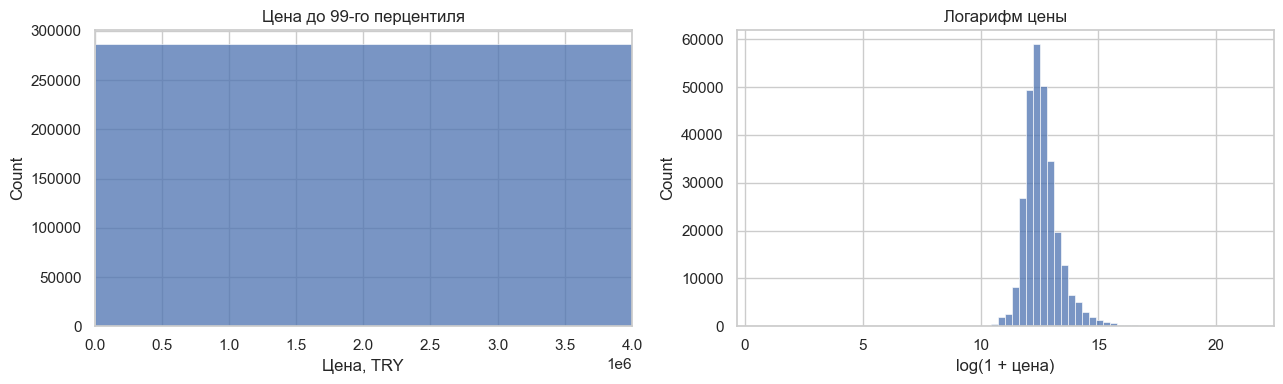

In [6]:
# Сравниваем хвост цены в обычном и логарифмическом масштабе.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(sale.price, bins=70, ax=ax[0])
ax[0].set(xlim=(0, sale.price.quantile(.99)), xlabel="Цена, TRY", title="Цена до 99-го перцентиля")
sns.histplot(np.log1p(sale.price), bins=70, ax=ax[1])
ax[1].set(xlabel="log(1 + цена)", title="Логарифм цены")
plt.tight_layout(); plt.show()

Логарифм делает распределение цены удобнее для анализа: огромные значения меньше доминируют на графике. Валидационные и тестовые цены остаются в TRY; после прогноза в логарифмах результат нужно вернуть в исходную шкалу.

## 2.3. Кодирование категориальных признаков

Номинальные признаки — город, район, тип жилья, отопление и разновидность этажа — кодируются One-Hot Encoding. Редкие категории (менее 100 записей в train) OneHotEncoder объединяет в группу редких значений. Это снижает размерность и позволяет обработать неизвестные категории в новых объявлениях.

Порядковые сведения об этажах, возрасте и комнатах сначала преобразуются в числа. Target encoding не используем: оно опирается на цену и требует особенно осторожной кросс-валидации, чтобы не допустить утечки.

In [7]:
# Разбор без обучения показывает кардинальность категорий.
parsed_for_review = builder.transform(sale.drop(columns=["price"]))
category_counts = pd.DataFrame({
    "Признак": CATEGORICAL_FEATURES,
    "Уникальных значений": [parsed_for_review[col].nunique(dropna=True) for col in CATEGORICAL_FEATURES],
    "Пустых": [parsed_for_review[col].isna().sum() for col in CATEGORICAL_FEATURES],
})
show_table(category_counts)

Признак,Уникальных значений,Пустых
city,82,0
district,580,5
sub_type,12,0
heating_type,16,18 272
floor_kind,8,24 721


Район имеет сотни значений — прямое создание столбца для каждого редкого района усложнило бы модель. Группировка редких категорий выполняется во время fit на train, а не по всей выборке.

## 2.4. Создание и отбор признаков

Полезные признаки: город и район из адреса, число комнат и гостиных из записи вида 2+1, возраст здания как число/середина диапазона, этаж как число, отношение этажа к этажности, флаги верхнего этажа, нового здания и отсутствующих значений. Это доступно при публикации объявления.

Признак цена/м² **не создаём** для модели: он вычисляется из целевой цены и мгновенно выдаст правильный ответ. Расстояние до центра не вычисляем без координат: выдуманное расстояние ухудшит достоверность. Примерный год постройки также не нужен: возраст здания уже есть, а добавление почти того же признака усилило бы зависимость столбцов.

In [8]:
# Перечень используемых и запрещённых входных полей.
features_table = pd.DataFrame({
    "Тип": ["Числовые", "Категориальные", "Исключены из входа"],
    "Поля": [", ".join(NUMERIC_FEATURES), ", ".join(CATEGORICAL_FEATURES), ", ".join(FORBIDDEN_INPUTS)],
})
show_table(features_table)

Тип,Поля
Числовые,"size_m2, bedrooms, living_rooms, building_age_years, building_floors, floor_number, floor_ratio, size_missing, age_missing, is_new_building, is_top_floor"
Категориальные,"city, district, sub_type, heating_type, floor_kind"
Исключены из входа,"id, price, end_date, tom, price_currency, listing_type, furnished, original_currency, exchange_rate, rate_date"


В модель поступят только признаки из первых двух строк таблицы. id, будущие даты, срок на рынке и цена не попадут в матрицу признаков. Проверка VIF для числовых полей проводится ниже исключительно на train.

## 2.5. Масштабирование признаков

Для линейных моделей используется StandardScaler после заполнения и ограничения экстремальной площади; параметры среднего и стандартного отклонения вычисляются на train. Для деревьев масштабирование не требуется, поэтому будет второй конвейер без StandardScaler. MinMaxScaler сильнее зависит от экстремумов; RobustScaler допустим, но после ограничения площади стандартное масштабирование проще интерпретировать.

In [9]:
# Создаём два независимых конвейера. Пока они НЕ обучены.
linear_preprocessor = make_preprocessor(scale_numeric=True, min_frequency=100)
tree_preprocessor = make_preprocessor(scale_numeric=False, min_frequency=100)
print("Линейная модель: числовые признаки -> медиана -> StandardScaler; категории -> мода -> One-Hot")
print("Деревья: числовые признаки -> медиана без масштаба; категории -> мода -> One-Hot")

Линейная модель: числовые признаки -> медиана -> StandardScaler; категории -> мода -> One-Hot
Деревья: числовые признаки -> медиана без масштаба; категории -> мода -> One-Hot


Оба конвейера используют одинаковый разбор данных, групповые медианы и кодирование категорий. Отличается только масштабирование чисел, поэтому сравнение моделей на следующем этапе будет корректным.

## 2.6. Разбиение данных и защита от утечки

Разбиваем на train/validation/test примерно 70/15/15 с RANDOM_STATE=42. Все объявления с одинаковыми адресом, типом, комнатами и площадью попадают в одну часть. Validation нужна для выбора моделей и настроек, test остаётся нетронутым до финальной оценки. Группы строятся только по входным полям, без цены. Это уменьшает риск почти одинаковых объектов в train и test. Настоящего идентификатора объекта нет, поэтому риск повторов с изменёнными характеристиками остаётся; для будущих лет полезен отдельный временной тест.

In [10]:
# Разбиваем до fit любой статистики заполнения, клиппинга, масштаба или кодирования.
(X_train, y_train), (X_val, y_val), (X_test, y_test) = split_sale_data(normalized, random_state=RANDOM_STATE)
assert set(X_train.id).isdisjoint(X_val.id)
assert set(X_train.id).isdisjoint(X_test.id)
assert set(X_val.id).isdisjoint(X_test.id)
# Группы похожих объектов не должны пересекаться между частями.
group_cols = ["address", "sub_type", "room_count", "size"]
group_hashes = [set(pd.util.hash_pandas_object(part[group_cols], index=False).tolist())
                for part in [X_train, X_val, X_test]]
assert group_hashes[0].isdisjoint(group_hashes[1])
assert group_hashes[0].isdisjoint(group_hashes[2])
assert group_hashes[1].isdisjoint(group_hashes[2])
split_summary = pd.DataFrame({
    "Выборка": ["Train", "Validation", "Test"],
    "Объявлений": [len(X_train), len(X_val), len(X_test)],
    "Доля, %": [100*len(X_train)/len(sale),100*len(X_val)/len(sale),100*len(X_test)/len(sale)],
    "Медиана цены, TRY": [y_train.median(), y_val.median(), y_test.median()],
})
show_table(split_summary)

Выборка,Объявлений,"Доля, %","Медиана цены, TRY"
Train,200 662,70.07,270 000.00
Validation,42 720,14.92,275 000.00
Test,43 010,15.02,270 000.00


Полученное разбиение близко к 70/15/15; фактические размеры и медианы приведены в таблице выше. ID и группы похожих объявлений между частями не пересекаются. Одинаковую квартиру с изменённым адресом или площадью эта проверка может не распознать.

In [11]:
# Сохраняем состав выборок для одинаковых экспериментов всей команды.
split_ids = pd.concat([
    pd.DataFrame({"id": X_train.id, "split": "train"}),
    pd.DataFrame({"id": X_val.id, "split": "validation"}),
    pd.DataFrame({"id": X_test.id, "split": "test"}),
]).sort_values("id")
processed_dir = ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
split_path = processed_dir / "split_ids.csv"
split_ids.to_csv(split_path, index=False)
print("Сохранены фиксированные ID разбиения:", split_path, "строк:", len(split_ids))

Сохранены фиксированные ID разбиения: C:\ForesightEstate\data\processed\split_ids.csv строк: 286392


Файл с ID позволяет команде повторить те же эксперименты, даже если порядок исходных строк позже изменится. Сам test по-прежнему нельзя использовать для настройки модели.

In [12]:
# fit_transform вызывается только на train; val/test проходят только transform.
start = time.perf_counter()
X_train_linear = linear_preprocessor.fit_transform(X_train)
X_val_linear = linear_preprocessor.transform(X_val)
X_test_linear = linear_preprocessor.transform(X_test)
X_train_tree = tree_preprocessor.fit_transform(X_train)
X_val_tree = tree_preprocessor.transform(X_val)
X_test_tree = tree_preprocessor.transform(X_test)
elapsed = time.perf_counter() - start
matrix_summary = pd.DataFrame({
    "Матрица": ["Train / linear","Validation / linear","Test / linear",
               "Train / tree","Validation / tree","Test / tree"],
    "Строк": [x.shape[0] for x in [X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree]],
    "Столбцов": [x.shape[1] for x in [X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree]],
    "Разреженная": [sparse.issparse(x) for x in [X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree]],
})
show_table(matrix_summary)
print("Время подготовки всех матриц, секунд:", round(elapsed, 1))

Матрица,Строк,Столбцов,Разреженная
Train / linear,200 662,324,True
Validation / linear,42 720,324,True
Test / linear,43 010,324,True
Train / tree,200 662,324,True
Validation / tree,42 720,324,True
Test / tree,43 010,324,True


Время подготовки всех матриц, секунд: 16.8


Количество столбцов одинаково в train/validation/test: кодировщик обучился на train и одинаково преобразовал остальные части. Разреженный формат экономит память, потому что One-Hot создаёт много нулей.

In [13]:
# Выводим только обученные на train медианы и пороги.
area_fitted = linear_preprocessor.named_steps["area_imputer"]
cap_fitted = linear_preprocessor.named_steps["capper"]
learned = pd.DataFrame({
    "Параметр": ["Общая медиана площади, м²", "Групп район+тип", "Групп город+тип",
                "Нижняя граница площади, м²", "Верхняя граница площади, м²"],
    "Значение": [area_fitted.global_median_, len(area_fitted.district_type_),
                len(area_fitted.city_type_), cap_fitted.bounds_["size_m2"][0],
                cap_fitted.bounds_["size_m2"][1]],
})
show_table(learned)

Параметр,Значение
"Общая медиана площади, м²",115.00
Групп район+тип,403.00
Групп город+тип,153.00
"Нижняя граница площади, м²",30.00
"Верхняя граница площади, м²",2 363.56


Медианы и пороги получены только из train. Неизвестный район сначала получает медиану города и типа жилья, затем типа жилья, затем общую медиану. Границы площади ориентировочно 31–1511 м²; они ограничивают вводимые модели экстремальные значения, не меняя исходный CSV.

In [14]:
# Проверяем численное качество матриц и отсутствие запрещённых полей.
feature_names = linear_preprocessor.named_steps["encode"].get_feature_names_out()
for matrix in [X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree]:
    values = matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    assert np.isfinite(values).all()
assert X_train_linear.shape[1] == X_val_linear.shape[1] == X_test_linear.shape[1]
assert X_train_tree.shape[1] == X_val_tree.shape[1] == X_test_tree.shape[1]
assert not any(name.split("__")[-1] in FORBIDDEN_INPUTS for name in feature_names)
print("Все матрицы конечны; форма согласована; запрещённые поля не вошли в признаки.")
print("Число итоговых признаков:", len(feature_names))
show_table(pd.DataFrame({"Первые признаки": feature_names[:18]}))

Все матрицы конечны; форма согласована; запрещённые поля не вошли в признаки.
Число итоговых признаков: 324


Первые признаки
numeric__size_m2
numeric__bedrooms
numeric__living_rooms
numeric__building_age_years
numeric__building_floors
numeric__floor_number
numeric__floor_ratio
numeric__size_missing
numeric__age_missing
numeric__is_new_building


Нет NaN и бесконечностей в итоговой матрице. Имя цены, ID и будущих полей отсутствуют в кодированных признаках. Полный список признаков доступен через get_feature_names_out() на обученном кодировщике.

In [15]:
# Неизвестные категории и пропущенная площадь в новой записи не требуют повторного fit.
probe = X_val.head(1).copy()
probe.loc[probe.index[0], "address"] = "НовыйГород/НовыйРайон/Улица"
probe.loc[probe.index[0], "sub_type"] = "НовыйТип"
probe.loc[probe.index[0], "size"] = np.nan
before = area_fitted.global_median_
probe_vector = linear_preprocessor.transform(probe)
after = area_fitted.global_median_
assert before == after and probe_vector.shape[1] == X_train_linear.shape[1]
print("Неизвестная категория обработана; площадь заполнена; обученная медиана не изменилась.")
print("Форма новой записи:", probe_vector.shape)

Неизвестная категория обработана; площадь заполнена; обученная медиана не изменилась.
Форма новой записи: (1, 324)


Конвейер умеет обрабатывать ранее не виденные категории без новой подгонки на validation/test. Это важно и для приложения: пользователь может выбрать объект из нового района.

### Проверка мультиколлинеарности на train

In [16]:
# VIF считаем на подвыборке train после заполнения/ограничения, но до One-Hot.
parsed_train = linear_preprocessor.named_steps["features"].transform(X_train)
imputed_train = area_fitted.transform(parsed_train)
capped_train = cap_fitted.transform(imputed_train)
vif_columns = ["size_m2","bedrooms","living_rooms","building_age_years",
               "building_floors","floor_number","floor_ratio"]
vif_sample = capped_train[vif_columns].sample(n=min(30000,len(capped_train)), random_state=RANDOM_STATE)
vif_array = SimpleImputer(strategy="median").fit_transform(vif_sample)
vif_array = np.column_stack([np.ones(len(vif_array)),vif_array])
vif_table = pd.DataFrame({"Признак":vif_columns,
                          "VIF":[variance_inflation_factor(vif_array,i+1) for i in range(len(vif_columns))]})
show_table(vif_table.sort_values("VIF",ascending=False))

Признак,VIF
floor_number,4.01
building_floors,2.56
floor_ratio,2.55
bedrooms,1.35
size_m2,1.23
living_rooms,1.14
building_age_years,1.02


Все VIF ниже 5, поэтому на этом этапе нет причины удалять числовые признаки только из-за мультиколлинеарности. В EDA площадь и число комнат сильно коррелировали на заполненных строках, но после группового заполнения и с учётом остальных признаков VIF остаётся умеренным. Если линейная модель будет нестабильна, пересмотрим состав признаков.

### Сохранение конвейеров

In [17]:
# Сохраняем обученные на train конвейеры для этапа моделей.
model_dir = ROOT / "models"
model_dir.mkdir(parents=True, exist_ok=True)
linear_path = model_dir / "preprocessor_linear.joblib"
tree_path = model_dir / "preprocessor_tree.joblib"
joblib.dump(linear_preprocessor, linear_path)
joblib.dump(tree_preprocessor, tree_path)
print("Линейный конвейер:", linear_path, "байт:", linear_path.stat().st_size)
print("Конвейер для деревьев:", tree_path, "байт:", tree_path.stat().st_size)

Линейный конвейер: C:\ForesightEstate\models\preprocessor_linear.joblib байт: 45870
Конвейер для деревьев: C:\ForesightEstate\models\preprocessor_tree.joblib байт: 45214


На этапе 3 модели будут обучаться с этими же преобразованиями. Для кросс-валидации важно включать предобработку **внутрь** каждой модели-пайплайна, чтобы медианы и кодировщик заново обучались только на тренировочной части каждого fold. Сохранённые здесь конвейеры подходят для финального обучения на фиксированном train, но не должны предварительно преобразовывать всю выборку перед GridSearchCV.

## Итог этапа 2

- Цены 1 924 объявлений в EUR/USD/GBP пересчитаны в TRY по датам публикации и официальным курсам TCMB; все курсы найдены, максимальное отставание 3 дня.
- Сформированы групповые train/validation/test примерно 70/15/15 без пересечения похожих объявлений и сохранены их ID.
- Пропуски обрабатываются по смыслу поля; площадь — групповой медианой train.
- Экстремальную площадь ограничивают перцентили train; целевая цена не подрезается.
- Номинальные поля кодируются One-Hot с группой редких категорий; порядковые сведения разобраны в числа.
- Добавлены признаки района, этажности, положения этажа и индикаторы пропусков. Цена/м², будущие поля и технический ID исключены.
- Для линейных моделей числа стандартизируются, для деревьев — нет. Числовые VIF ниже 5.
- Все вычисляемые параметры обучены на train; validation/test только преобразованы.

**Ограничения:** курс TCMB — справочный, а не цена фактической конвертации; пересчёт не устраняет изменение покупательной способности TRY за полгода. числовой смысл listing_type=1 нужно подтвердить у источника. Групповое случайное разбиение показывает качество на новых комбинациях исторических объявлений; для оценки работы в будущем стоит также провести проверку на более поздних датах.